# Contrast Stretching using Piecewise Linear Transformation

Slopes chosen are 0.5, 2, and 0.5

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## 2. Load and Prepare Image

In [ ]:
I = cv2.imread('cat.png', 0)  # Read the image in grayscale


## 3. Define Piecewise Linear Transformation Function

In [3]:
# Define parameters for piecewise linear transformation
LT = 100  # Lower threshold value
UT = 150  # Upper threshold value

def piecewise_linear_transform(pixel_value, LT, UT):
    if pixel_value <= LT:
        return 0.5 * pixel_value
    elif pixel_value <= UT:
        return 2 * (pixel_value - LT) + (0.5 * LT)
    else:
        return 0.5 * (pixel_value - UT) + (0.5 * LT) + 2 * (UT - LT)

## 4. Apply Contrast Stretching

In [4]:
# Apply piecewise linear transformation to the entire image
row, col = I.shape
I_str = np.zeros_like(I)

# Using vectorized operation for efficiency
for i in range(row):
    for j in range(col):
        I_str[i, j] = piecewise_linear_transform(I[i, j], LT, UT)

print(f"Contrast stretched image min: {I_str.min():.4f}, max: {I_str.max():.4f}")

Contrast stretched image min: 0.0000, max: 202.0000


## 5. Plot Transformation Function

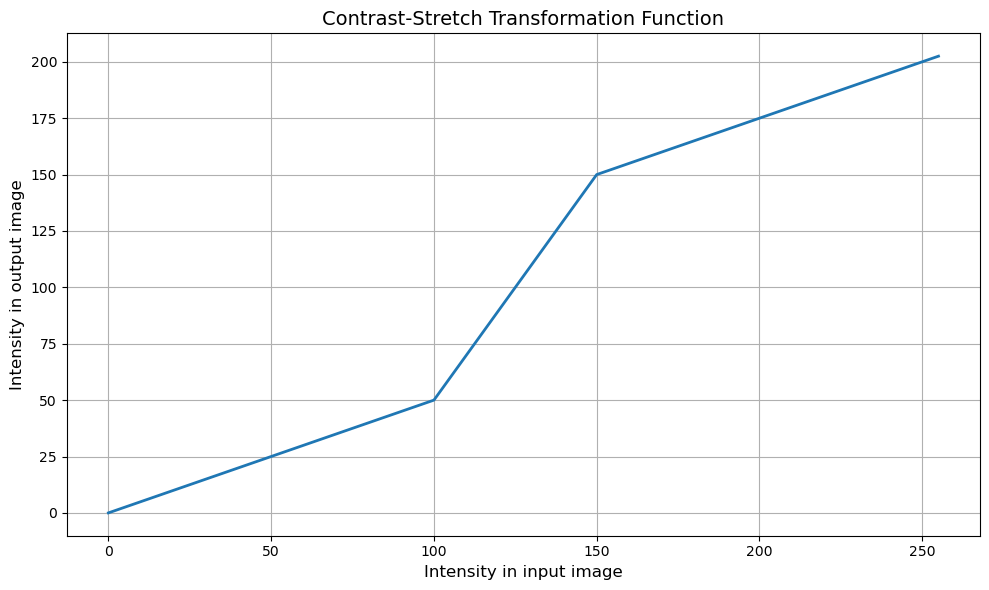

In [5]:
# Create transformation curve (similar to MATLAB code)
dd = np.zeros(256)

# Segment 1: 0 to LT (slope 0.5)
dd[0:LT] = 0.5 * np.arange(0, LT)

# Segment 2: LT to UT (slope 2)
dd[LT:UT] = 2 * (np.arange(LT, UT) - LT) + (0.5 * LT)

# Segment 3: UT to 256 (slope 0.5)
dd[UT:256] = 0.5 * (np.arange(UT, 256) - UT) + (0.5 * LT) + 2 * (UT - LT)

# Plot the transformation function
plt.figure(figsize=(10, 6))
plt.plot(dd, linewidth=2)
plt.grid(True)
plt.xlabel('Intensity in input image', fontsize=12)
plt.ylabel('Intensity in output image', fontsize=12)
plt.title('Contrast-Stretch Transformation Function', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Display Results

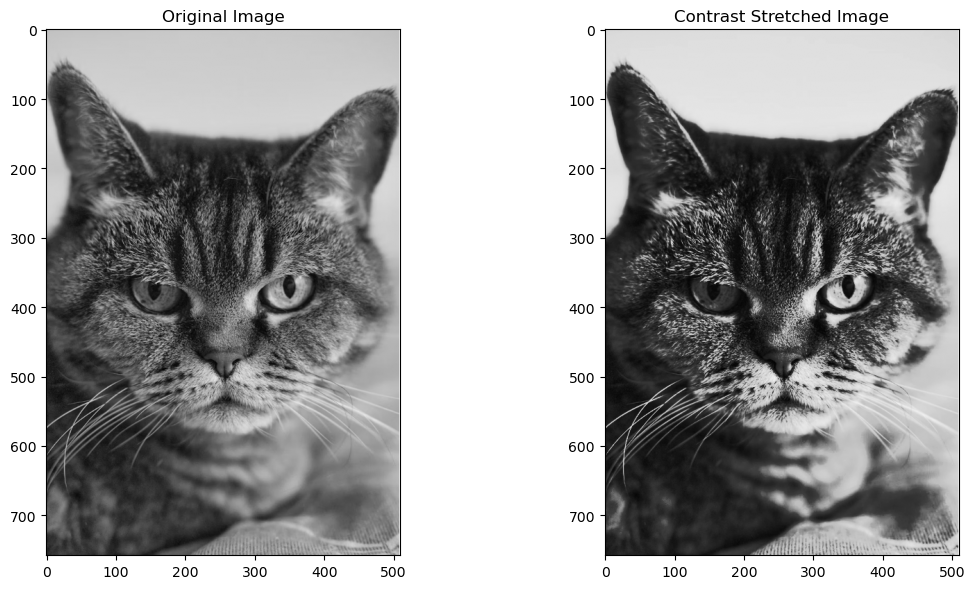

In [ ]:
# Display original and contrast-stretched images side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Original Image', fontsize=12)

plt.subplot(1, 2, 2)
plt.imshow(I_str, cmap='gray')
plt.title('Contrast Stretched Image', fontsize=12)
plt.tight_layout()
plt.show()